In [3]:
!pip install -q kaggle
!kaggle datasets download -d greatgamedota/ffhq-face-data-set
!unzip ffhq-face-data-set.zip -d ffhq-face-data-set/
from google.colab import drive
drive.mount('/content/drive')

A saída de streaming foi truncada nas últimas 5000 linhas.
  inflating: ffhq-face-data-set/thumbnails128x128/65001.png  
  inflating: ffhq-face-data-set/thumbnails128x128/65002.png  
  inflating: ffhq-face-data-set/thumbnails128x128/65003.png  
  inflating: ffhq-face-data-set/thumbnails128x128/65004.png  
  inflating: ffhq-face-data-set/thumbnails128x128/65005.png  
  inflating: ffhq-face-data-set/thumbnails128x128/65006.png  
  inflating: ffhq-face-data-set/thumbnails128x128/65007.png  
  inflating: ffhq-face-data-set/thumbnails128x128/65008.png  
  inflating: ffhq-face-data-set/thumbnails128x128/65009.png  
  inflating: ffhq-face-data-set/thumbnails128x128/65010.png  
  inflating: ffhq-face-data-set/thumbnails128x128/65011.png  
  inflating: ffhq-face-data-set/thumbnails128x128/65012.png  
  inflating: ffhq-face-data-set/thumbnails128x128/65013.png  
  inflating: ffhq-face-data-set/thumbnails128x128/65014.png  
  inflating: ffhq-face-data-set/thumbnails128x128/65015.png  
  inflating

(128, 128, 3)


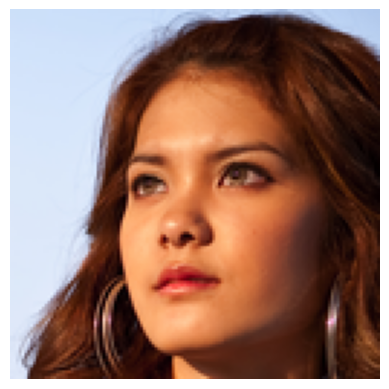

In [4]:
from matplotlib import pyplot as plt
import matplotlib.image as mpimg

# 1. Define your image file path
img_path = 'ffhq-face-data-set/thumbnails128x128/01996.png'

# 2. Read the image file into a NumPy array
img = mpimg.imread(img_path)
print(img.shape)

# 3. Display the image
plt.imshow(img)
plt.axis('off') # Optional: Hides the pixel coordinate axes
plt.show()

In [5]:
import tensorflow as tf
from tensorflow.keras import models, layers

def residual_block(x, filters):
    shortcut = x

    if x.shape[-1] != filters:
        shortcut = layers.Conv2D(
            filters,
            1,
            padding="same"
        )(shortcut)

    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2D(filters, 3, padding="same")(x)

    x = layers.Add()([x, shortcut])
    x = layers.LeakyReLU(0.2)(x)

    return x

In [6]:
def criar_critico():
  inputs = layers.Input((128,128,3))
  x = layers.Conv2D(64, 3, padding="same")(inputs)
  x = residual_block(x, 64)
  x = residual_block(x, 128)
  x = residual_block(x, 256)
  x = layers.GlobalAveragePooling2D()(x)
  x = layers.Dense(128)(x)
  outputs = layers.Dense(1)(x)
  return models.Model(inputs, outputs)
criar_critico().summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 128, 128,  │      1,792 │ input_layer_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 128, 128,  │     36,928 │ conv2d_9[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_6       │ (None, 128, 128,  │          0 │ conv2d_10[0][0]   │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 128, 128,  │     36,928 │ leaky_re_lu_6[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 128, 128,  │          0 │ conv2d_11[0][0],  │
│                     │ 64)               │            │ conv2d_9[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_7       │ (None, 128, 128,  │          0 │ add_3[0][0]       │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 128, 128,  │     73,856 │ leaky_re_lu_7[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_8       │ (None, 128, 128,  │          0 │ conv2d_13[0][0]   │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 128, 128,  │    147,584 │ leaky_re_lu_8[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 128, 128,  │      8,320 │ leaky_re_lu_7[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 128, 128,  │          0 │ conv2d_14[0][0],  │
│                     │ 128)              │            │ conv2d_12[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_9       │ (None, 128, 128,  │          0 │ add_4[0][0]       │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 128, 128,  │    295,168 │ leaky_re_lu_9[0]… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_10      │ (None, 128, 128,  │          0 │ conv2d_16[0][0]   │
│ (LeakyReLU)         │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 128, 128,  │    590,080 │ leaky_re_lu_10[0… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 128, 128,  │     33,024 │ leaky_re_lu_9[0]

 Total params: 1,256,705 (4.79 MB)

 Trainable params: 1,256,705 (4.79 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
GENERATOR_LATENT_DIM = 64
def mapping_network():
  inputs = layers.Input((GENERATOR_LATENT_DIM,))
  x = layers.Dense(GENERATOR_LATENT_DIM)(inputs)
  for _ in range(7):
      x = layers.Dense(GENERATOR_LATENT_DIM)(x)
  return  models.Model(inputs, x)


In [8]:
mapping_network().summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         4,160 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,280 (130.00 KB)

 Trainable params: 33,280 (130.00 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
class FourierInput(layers.Layer):

    def __init__(self, channels, out_size=128):
        super().__init__()

        self.channels = channels
        self.out_size = out_size

        self.affine = layers.Dense(2)

        self.frequencies = tf.Variable(
            tf.random.normal((channels,2)),
            trainable=True
        )

        self.phase = tf.Variable(
            tf.zeros((channels,)),
            trainable=True
        )
    def call(self, w):
        offset = self.affine(w)
        x = tf.linspace(-1.,1.,self.out_size)
        y = tf.linspace(-1.,1.,self.out_size)

        xx,yy = tf.meshgrid(x,y)

        coords = tf.stack([xx,yy],axis=-1)
        coords = coords[None] + offset[:,None,None,:]
        phase = tf.einsum(
            "bhwc,kc->bhwk",
            coords,
            self.frequencies
        )
        features = tf.sin(
            phase + self.phase
        )
        return features

In [10]:
batch_size = 4
GENERATOR_LATENT_DIM = 64

w = tf.random.normal((batch_size, GENERATOR_LATENT_DIM))
fourier = FourierInput(512)
features = fourier(w)
print(features.shape)
print(tf.reduce_min(features))
print(tf.reduce_max(features))

(4, 128, 128, 512)
tf.Tensor(-1.0, shape=(), dtype=float32)
tf.Tensor(1.0, shape=(), dtype=float32)


In [11]:
class SynthesisLayer(layers.Layer):
    def __init__(self, in_channels, out_channels, kernel_size=3, demodulate=True, **kwargs):
        super().__init__(**kwargs)
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.demodulate = demodulate
        self.eps = 1e-8
        # 1. Função Afim (A): Transforma o vetor de estilo w na escala s
        self.affine = layers.Dense(in_channels)

        # 2. Pesos do Kernel da Convolução (o "w2" do diagrama)
        # Formato no Keras: [altura, largura, in_channels, out_channels]
        self.kernel = self.add_weight(
            name="kernel",
            shape=[kernel_size, kernel_size, in_channels, out_channels],
            initializer="glorot_uniform",
            trainable=True,
        )
    def call(self, w, x):
        # -----------------------------------------------------------------
        # PASSO 1: Função Afim -> s = A(w)
        # Transforma w em escala por canal de entrada [batch, in_channels]
        # Expandido para [batch, 1, 1, in_channels, 1] para broadcasting
        # -----------------------------------------------------------------
        s = self.affine(w)
        s_expanded = s[:, tf.newaxis, tf.newaxis, :, tf.newaxis]

        # -----------------------------------------------------------------
        # PASSO 2: Modulação (Mod) -> W' = s * W
        # Multiplica os pesos base (w2) pela escala s de cada amostra
        # Resultado shape: [batch, k_h, k_w, in_channels, out_channels]
        # -----------------------------------------------------------------
        w_prime = self.kernel[tf.newaxis, ...] * s_expanded
        # -----------------------------------------------------------------
        # PASSO 3: Demodulação (Demod)
        # Normaliza os pesos modulados para manter variância unitária
        # -----------------------------------------------------------------
        if self.demodulate:
            # Soma dos quadrados sobre a janela de convolução e canais de entrada
            demod_factor = tf.math.rsqrt(
                tf.reduce_sum(tf.square(w_prime), axis=[1, 2, 3], keepdims=True) + self.eps
            )
            w_prime = w_prime * demod_factor

        # -----------------------------------------------------------------
        # PASSO 4: Convolução com pesos dinâmicos por amostra
        # -----------------------------------------------------------------
        def apply_single_conv(args):
            x_i, w_i = args  # x_i: [H, W, in_ch], w_i: [k_h, k_w, in_ch, out_ch]
            return tf.nn.conv2d(x_i[tf.newaxis, ...], w_i, strides=1, padding="SAME")[0]

        # Processa cada par (imagem_i, pesos_i) do batch
        out = tf.map_fn(
            apply_single_conv,
            elems=(x, w_prime),
            fn_output_signature=tf.float32
        )

        return out

In [12]:
def synthesis_network():
    inputs = layers.Input((64,))
    fourier_input = FourierInput(512)(inputs)
    x = layers.Conv2D(filters=128, kernel_size=1, padding="same")(fourier_input)
    for i in range(2):
        x = SynthesisLayer(128,128,3)(inputs, x)
    x = SynthesisLayer(128,3,3)(inputs, x)
    model = tf.keras.Model(inputs, x)
    return model
synthesis_network().summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 64)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fourier_input_1     │ (None, 128, 128,  │        130 │ input_layer_3[0]… │
│ (FourierInput)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 128, 128,  │     65,664 │ fourier_input_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ synthesis_layer     │ (None, 128, 128,  │    155,776 │ input_layer_3[0]… │
│ (SynthesisLayer)    │ 128)              │            │ conv2d_18[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ synthesis_layer_1   │ (None, 128, 128,  │    155,776 │ input_layer_3[0]… │
│ (SynthesisLayer)    │ 128)              │            │ synthesis_layer[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ synthesis_layer_2   │ (None, 128, 128,  │     11,776 │ input_layer_3[0]… │
│ (SynthesisLayer)    │ 3)                │            │ synthesis_layer_… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 389,122 (1.48 MB)

 Trainable params: 389,122 (1.48 MB)

 Non-trainable params: 0 (0.00 B)

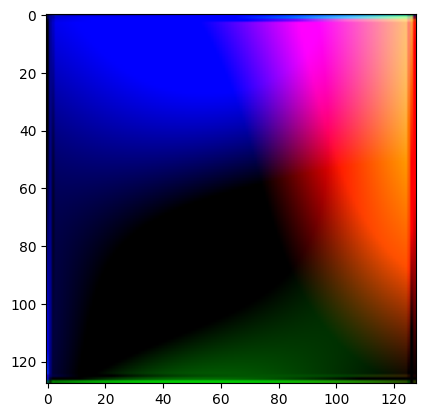

In [13]:
from keras.optimizers import Adam
gerador = synthesis_network()

critico = criar_critico()
optimizer_gerador = Adam(learning_rate=0.0001, beta_1=0.0, beta_2=0.9)

optimizer_critico = Adam(learning_rate=0.0001, beta_1=0.0, beta_2=0.9)
# CHECKPOINTS DEFINITION AND RESTORATION

ckpt = tf.train.Checkpoint(
    gerador=gerador,
    critico=critico,
    optimizer_gerador=optimizer_gerador,
    optimizer_critico=optimizer_critico,
    epoch=tf.Variable(0),
    batch=tf.Variable(0)
)
plt.imshow(gerador(tf.random.normal((1,GENERATOR_LATENT_DIM))).numpy()[0])

In [14]:
def train_critic(
    imagens_reais,
    optimizer_critico,
    batch_size,
    lambda_gp
  ):
  print("Entrou no train_critic")
  batch = tf.shape(imagens_reais)[0]
  z = tf.random.normal((batch, GENERATOR_LATENT_DIM), dtype=tf.float32)
  imagens_geradas = tf.stop_gradient(
      gerador(z, training=False)
  )
  # print(imagens_geradas.shape)
  with tf.GradientTape() as tape:
      y_pred_gerado = critico(imagens_geradas, training=True)
      y_pred_real = critico(imagens_reais, training=True)
      y_pred_real = tf.debugging.check_numerics(y_pred_real, "critic_real")
      epsilon = tf.random.uniform(
          [batch,1,1,1], dtype=tf.float32
      )
      x_hat = (
          epsilon*imagens_reais
          +
          (one-epsilon)*imagens_geradas
      )
      with tf.GradientTape() as gp_tape:
          gp_tape.watch(x_hat)
          pred = critico(x_hat, training=True)
      grad = gp_tape.gradient(pred, x_hat)
      del gp_tape
      grad = tf.debugging.check_numerics(grad, "gp_grad")
      norm = tf.sqrt(tf.reduce_sum(tf.square(grad), axis=[1,2,3]) + 1e-12)
      norm = tf.debugging.check_numerics(norm, "gp_norm")
      gp = tf.reduce_mean(
          (norm - one) ** 2
      )
      gp = tf.debugging.check_numerics(gp, "gp_value")
      loss_critico = tf.reduce_mean(y_pred_gerado) - tf.reduce_mean(y_pred_real) + lambda_gp*gp
      loss_critico = tf.debugging.check_numerics(loss_critico, "loss_critico")
  grads_critico = tape.gradient(loss_critico, critico.trainable_variables)
  max_grad_abs = tf.reduce_max([tf.reduce_max(tf.abs(g)) for g in grads_critico])

  grads_critico, _ = tf.clip_by_global_norm(grads_critico, 5.0)

  optimizer_critico.apply_gradients(zip(grads_critico, critico.trainable_variables))
  for i, v in enumerate(critico.trainable_variables):
    if tf.reduce_any(tf.math.is_nan(v)):
        print(f"Critico corrompeu: index={i}, name={v.name}, path={v.path}, shape={v.shape}")
        raise RuntimeError("NaN no crítico")

def train_generator(
    imagens_reais,
    optimizer_gerador,
    batch_size,
    lambda_gp,
    tamanho_batch_atual
):
  batch = tf.shape(imagens_reais)[0]
  z = tf.random.normal((tamanho_batch_atual, GENERATOR_LATENT_DIM), dtype=tf.float32)
  with tf.GradientTape() as tape:
      imagens_geradas = gerador(z, training=True)
      y_pred_gerado = critico(imagens_geradas, training=False)
      loss_gerador = -tf.reduce_mean(y_pred_gerado)

  grads_gerador = tape.gradient(loss_gerador, gerador.trainable_variables)
  optimizer_gerador.apply_gradients(
      zip(grads_gerador, gerador.trainable_variables)
  )
  for i, v in enumerate(gerador.trainable_variables):
    if tf.reduce_any(tf.math.is_nan(v)):
        print(f"Gerador corrompeu: index={i}, name={v.name}, path={v.path}, shape={v.shape}")
        raise RuntimeError("NaN no gerador")


In [15]:
import os
pasta_das_imagens = 'ffhq-face-data-set/thumbnails128x128'
n_imagens = len(os.listdir(pasta_das_imagens))

In [16]:
def images_generator():
    for image_path in os.listdir(pasta_das_imagens):
        yield tf.image.convert_image_dtype(tf.image.decode_png(tf.io.read_file(f"{pasta_das_imagens}/{image_path}")), tf.float32)

In [ ]:
import math
from tqdm.notebook import tqdm
from keras.losses import BinaryCrossentropy
from keras.optimizers import Adam
import pickle
import time


batch_size = 16
epochs = 50
lambda_gp = 10
num_batches = int(math.ceil(n_imagens/batch_size))
n_critic = 5
save_interval = 10
dataset = tf.data.Dataset.from_generator(images_generator, output_signature=tf.TensorSpec(shape=(128, 128, 3), dtype=tf.float32))
dataset = dataset.shuffle(
    n_imagens
).batch(
    batch_size
).prefetch(
    tf.data.AUTOTUNE
)
# if tf.config.list_physical_devices('GPU'):
#   device = '/device:GPU:0'
#else:
#  device = '/device:CPU:0'
gpus = tf.config.list_physical_devices('GPU')
if len(gpus) > 1:
    strategy = tf.distribute.MirroredStrategy()
    print(f"🚀 Treinando em Paralelo com {strategy.num_replicas_in_sync} GPUs!")
else:
    strategy = tf.distribute.get_strategy()
    print("⚠️ Apenas 1 GPU ou CPU detectada.")
with strategy.scope():
  #@tf.function
  def distributed_train_critic(images):
      strategy.run(train_critic, args=(images,
                                      optimizer_critico,
                                      batch_size,
                                      lambda_gp))
  #@tf.function
  def distributed_train_generator(images):
     strategy.run(train_generator, args=(
                                     images,
                                     optimizer_gerador,
                                     batch_size,
                                     lambda_gp,
                                     tamanho_batch_atual))
  dist_dataset = strategy.experimental_distribute_dataset(dataset)
  gerador = synthesis_network()
  critico = criar_critico()

  optimizer_gerador = Adam(learning_rate=0.0001, beta_1=0.0, beta_2=0.9)
  optimizer_critico = Adam(learning_rate=0.0001, beta_1=0.0, beta_2=0.9)

  # CHECKPOINTS DEFINITION AND RESTORATION
  ckpt = tf.train.Checkpoint(
      gerador=gerador,
      critico=critico,
      optimizer_gerador=optimizer_gerador,
      optimizer_critico=optimizer_critico,
      epoch=tf.Variable(0),
      batch=tf.Variable(0)
  )

  manager = tf.train.CheckpointManager(
      ckpt,
      "drive/MyDrive/machine_learning_systems_output/FFHQ/checkpoints",
      max_to_keep=1
  )
  print(manager.latest_checkpoint)
  ckpt.restore(manager.latest_checkpoint)

  initial_epoch = 0
  initial_batch = 0
  if manager.latest_checkpoint:
      print("Checkpoint carregado!")
      print("Época:", int(ckpt.epoch))
      print("Batch:", int(ckpt.batch))
      initial_epoch =  int(ckpt.epoch.numpy())
      initial_batch = int(ckpt.batch.numpy())
  else:
      print("Treinamento do zero.")
  one = tf.constant(1.0, dtype=tf.float32)
  for epoch in tqdm(
      range(initial_epoch, epochs),
      initial=initial_epoch,
      total=epochs,
      desc="epoch"
  ):
      start_batch = initial_batch if epoch == initial_epoch else 0
      dataset_epoch = dataset.skip(start_batch)
      for batch_index, imagens_reais in tqdm(
          enumerate(dataset_epoch, start=start_batch),
          initial=start_batch,
          total=num_batches,
          desc="batch",
          leave=False
      ):
          if batch_index < start_batch:
              continue

          tamanho_batch_atual = imagens_reais.shape[0]
          ruido = tf.random.normal(
              imagens_reais.shape,
              stddev=0.05,
              dtype=imagens_reais.dtype
          )
          imagens_reais += ruido
          imagens_reais = tf.clip_by_value(
              imagens_reais,
              -1.0,
              1.0
          )
          for _ in range(n_critic):
            distributed_train_critic(imagens_reais)
          distributed_train_generator(imagens_reais)
          print(
                len(gerador.variables),
                len(critico.variables),
                len(optimizer_gerador.variables),
                len(optimizer_critico.variables)
            )
          if batch_index % save_interval == 0:
            if batch_index == num_batches - 1:
              ckpt.epoch.assign(epoch + 1)
              ckpt.batch.assign(0)
            else:
              ckpt.epoch.assign(epoch)
              ckpt.batch.assign(batch_index + 1)
            save_path = manager.save()
            print("Checkpoint salvo em:", save_path)

⚠️ Apenas 1 GPU ou CPU detectada.
None
Treinamento do zero.


epoch:   0%|          | 0/50 [00:00<?, ?it/s]

batch:   0%|          | 0/4375 [00:00<?, ?it/s]

In [ ]:
os.makedirs('drive/MyDrive/machine_learning_systems_output/FFHQ/generator_outputs', exist_ok=True)
z = z = tf.random.normal((10, GENERATOR_LATENT_DIM))
imagens = gerador(z)
print(imagens.shape)
print(imagens.dtype)

print(tf.reduce_min(imagens))
print(tf.reduce_max(imagens))

print(tf.math.reduce_any(tf.math.is_nan(imagens)))
print(tf.math.reduce_any(tf.math.is_inf(imagens)))
for i in range(10):
    plt.figure()
    plt.imsave(f'drive/MyDrive/machine_learning_systems_output/FFHQ/generator_outputs/{i}.png', tf.squeeze(imagens[i]), cmap="gray")